# hybrid_thermal Inference

Run one RGB drone image through the ThermalGen thermal evidence model and preview the generated grayscale thermal map.

Before running this notebook, install the backend dependencies in the selected kernel environment:

```powershell
python -m pip install -r backend\requirements.txt
```

In [4]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'backend').exists() and (candidate / 'readme.md').exists():
            return candidate
    raise RuntimeError('Could not find UrbanLens repo root.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATASET_RGB_DIR = REPO_ROOT / 'backend' / 'data' / 'hybrid_thermal' / 'RGB_to_thermal_dataset' / 'Test' / 'RGB'
PREDICT_DIR = REPO_ROOT / 'backend' / 'data' / 'hybrid_thermal' / 'Predict_Thermal'
ALIGNED_DIR = REPO_ROOT / 'backend' / 'data' / 'hybrid_thermal' / 'Test_RGB_centercrop_640x512'

rgb_files = sorted(DATASET_RGB_DIR.glob('*.JPG')) + sorted(DATASET_RGB_DIR.glob('*.jpg')) + sorted(DATASET_RGB_DIR.glob('*.jpeg'))
assert rgb_files, f'No RGB files found in {DATASET_RGB_DIR}'

INPUT_IMAGE = rgb_files[0]
print('Repo root:', REPO_ROOT)
print('Input image:', INPUT_IMAGE)

Repo root: C:\Users\webga\OneDrive\Documents\GitHub\UrbanLens
Input image: C:\Users\webga\OneDrive\Documents\GitHub\UrbanLens\backend\data\hybrid_thermal\RGB_to_thermal_dataset\Test\RGB\487.JPG


In [5]:
from backend.app.thermal.hybrid_thermal.runtime import predict_one

result = predict_one(INPUT_IMAGE, output_dir=PREDICT_DIR, aligned_dir=ALIGNED_DIR)
result

{'aligned_rgb_path': 'C:\\Users\\webga\\OneDrive\\Documents\\GitHub\\UrbanLens\\backend\\data\\hybrid_thermal\\Test_RGB_centercrop_640x512\\487.png',
 'thermal_image_path': 'C:\\Users\\webga\\OneDrive\\Documents\\GitHub\\UrbanLens\\backend\\data\\hybrid_thermal\\Predict_Thermal\\487.png',
 'thermal_preview_path': 'C:\\Users\\webga\\OneDrive\\Documents\\GitHub\\UrbanLens\\backend\\data\\hybrid_thermal\\Predict_Thermal\\487_thermal_preview.png',
 'checkpoint_path': 'C:\\Users\\webga\\OneDrive\\Documents\\GitHub\\UrbanLens\\backend\\models\\hybrid_thermal\\checkpoints\\best_psnr.pth',
 'thermal_data': {'min_temp_c': 28.8,
  'max_temp_c': 45.6,
  'mean_temp_c': 36.8,
  'hotspot_regions': [{'centroid_px': {'x': 145.49946466809422,
     'y': 154.67430406852247},
    'bbox_px': {'x': 115, 'y': 30, 'w': 78, 'h': 226},
    'intensity': 0.7773,
    'area_px': 9340},
   {'centroid_px': {'x': 28.321902464242633, 'y': 135.84335688437017},
    'bbox_px': {'x': 1, 'y': 73, 'w': 64, 'h': 115},
    'in


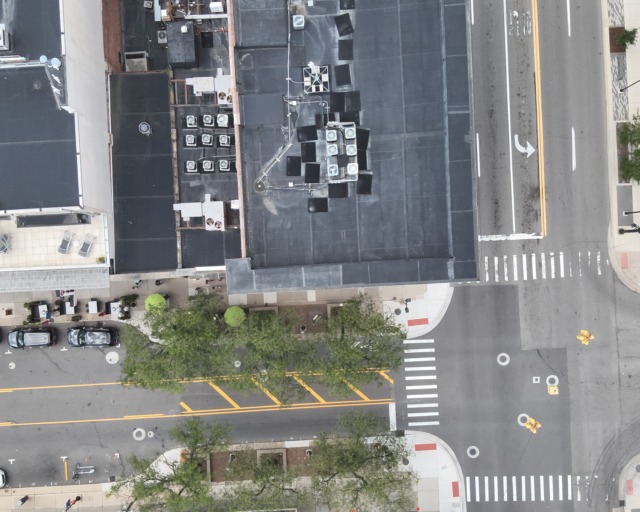
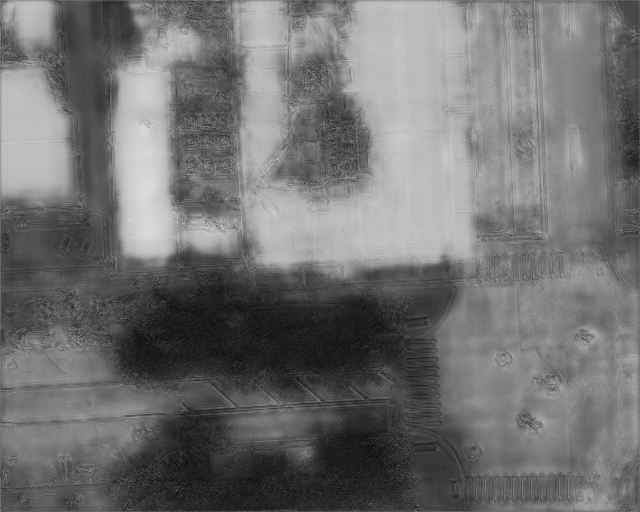
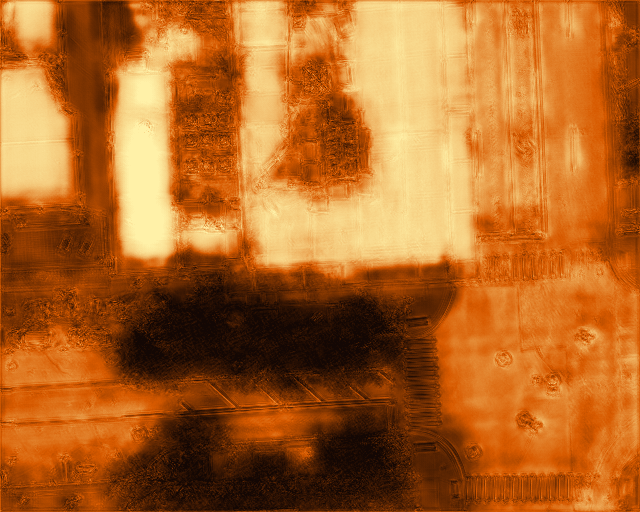

Aligned RGB: C:\Users\webga\OneDrive\Documents\GitHub\UrbanLens\backend\data\hybrid_thermal\Test_RGB_centercrop_640x512\487.png
Predicted thermal grayscale: C:\Users\webga\OneDrive\Documents\GitHub\UrbanLens\backend\data\hybrid_thermal\Predict_Thermal\487.png
Autocontrast thermal preview: C:\Users\webga\OneDrive\Documents\GitHub\UrbanLens\backend\data\hybrid_thermal\Predict_Thermal\487_thermal_preview.png
Thermal stats: 28.8 36.8 45.6
Hotspot regions: 5


In [6]:
from base64 import b64encode
from IPython.display import HTML, display

aligned_path = Path(result['aligned_rgb_path'])
thermal_path = Path(result['thermal_image_path'])
thermal_preview_path = Path(result['thermal_preview_path'])

def image_data_uri(path: Path) -> str:
    encoded = b64encode(path.read_bytes()).decode('ascii')
    return f'data:image/png;base64,{encoded}'

display(HTML(f'''
<div style="display:flex;gap:16px;align-items:flex-start;flex-wrap:wrap;font-family:Arial,sans-serif">
  <div><h3>Aligned RGB</h3><img src="{image_data_uri(aligned_path)}" style="width:340px;max-width:100%;border:1px solid #ccc"></div>
  <div><h3>Thermal prediction, grayscale source</h3><img src="{image_data_uri(thermal_path)}" style="width:340px;max-width:100%;border:1px solid #ccc"></div>
  <div><h3>Thermal prediction, autocontrast preview</h3><img src="{image_data_uri(thermal_preview_path)}" style="width:340px;max-width:100%;border:1px solid #ccc"></div>
</div>
'''))

print('Aligned RGB:', aligned_path)
print('Predicted thermal grayscale:', thermal_path)
print('Autocontrast thermal preview:', thermal_preview_path)
print('Thermal stats:', result['thermal_data']['min_temp_c'], result['thermal_data']['mean_temp_c'], result['thermal_data']['max_temp_c'])
print('Hotspot regions:', len(result['thermal_data']['hotspot_regions']))

## Use A Different Image

Set `INPUT_IMAGE` to another local RGB file and rerun the prediction cell:

```python
INPUT_IMAGE = REPO_ROOT / 'backend/data/hybrid_thermal/RGB_to_thermal_dataset/Test/RGB/507.JPG'
result = predict_one(INPUT_IMAGE, output_dir=PREDICT_DIR, aligned_dir=ALIGNED_DIR)
```